# M2b — LSTM AE + MC Dropout · Low-Dropout Ablation

In [5]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
# ── Environment ───────────────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Datasets ──────────────────────────────────────────────────────────────────
DATASETS = {
    "SKAB": {
        "npy_dir":    "npy_skab",
        "hf_dataset": "skab-anomaly-detection",
        "window_size": 30,
        "n_features":  8,
    },
    "NAB": {
        "npy_dir":    "npy_nab",
        "hf_dataset": "nab-anomaly-detection",
        "window_size": 50,
        "n_features":  1,
    },
}

# ── Dropout sweep — the only axis we vary ─────────────────────────────────────
DROPOUT_SWEEP = [0.001, 0.005, 0.01, 0.02, 0.05]   # 0.05 = M2 reference

# ── Fixed HPs — M2 winners (do NOT change) ────────────────────────────────────
# These were found via 27-combo search in 05_LSTM_AE_MCD.ipynb.
FIXED_HP = {
    "SKAB": {"latent_dim": 32, "lr": 1e-3},
    "NAB":  {"latent_dim": 64, "lr": 1e-3},
}
LSTM_HIDDEN_DIM = 64   # same as M2

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS     = 100
BATCH_SIZE = 256
PATIENCE   = 10
T_MC       = 50

# ── HF / W&B ──────────────────────────────────────────────────────────────────
PUSH_TO_HUB     = False          # ablation only — no HF commits
USE_WANDB       = True           # ← set True on RunPod so results are tracked
WANDB_PROJECT   = "iot-ad-mcd"  # same project as 05, separate runs by name
MODEL_REPO_NAME = "iot-ad-models"

# ── Misc ──────────────────────────────────────────────────────────────────────
SEED          = 42
OUTPUT_DIR    = "outputs"
CKPT_DIR      = "models/checkpoints"
RESULTS_FILE  = f"{OUTPUT_DIR}/baseline_results.json"
THRESHOLD_PCT = 95

In [7]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, precision_recall_curve,
)
from huggingface_hub import HfApi

# ── Credentials ───────────────────────────────────────────────────────────────
if IN_COLAB:
    from google.colab import userdata

    def _secret(key, default=""):
        # userdata.get() takes exactly ONE argument — no default parameter
        try:
            return userdata.get(key)
        except Exception:
            return default

    HF_USERNAME  = _secret("HF_USERNAME")
    HF_TOKEN     = _secret("HF_TOKEN")
    WANDB_KEY    = _secret("WANDB_API_KEY")
    WANDB_ENTITY = _secret("WANDB_ENTITY")
    if USE_WANDB:
        import wandb
        if WANDB_KEY:
            wandb.login(key=WANDB_KEY)
        else:
            wandb.login()
else:
    from dotenv import load_dotenv
    load_dotenv()
    HF_USERNAME  = os.getenv("HF_USERNAME")
    HF_TOKEN     = os.getenv("HF_TOKEN")
    WANDB_KEY    = os.getenv("WANDB_API_KEY", "")
    WANDB_ENTITY = os.getenv("WANDB_ENTITY", "")   # your W&B username
    if USE_WANDB:
        import wandb
        if WANDB_KEY:
            wandb.login(key=WANDB_KEY, relogin=True)
        else:
            print("⚠ WANDB_API_KEY not set in .env — running offline")
            os.environ["WANDB_MODE"] = "offline"

if not HF_USERNAME or not HF_TOKEN:
    raise EnvironmentError(
        "HF_USERNAME or HF_TOKEN not found. "
        "Local: add to .env | Colab: add to Secrets panel."
    )

# ── Setup ─────────────────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,   exist_ok=True)
MODEL_REPO_ID = f"{HF_USERNAME}/{MODEL_REPO_NAME}"
api = HfApi()

print(f"Environment : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Device      : {device}")
print(f"Dropout sweep : {DROPOUT_SWEEP}")
print(f"  → SKAB fixed HP: {FIXED_HP['SKAB']}")
print(f"  → NAB  fixed HP: {FIXED_HP['NAB']}")
print("Imports OK")

⚠ WANDB_API_KEY not set in .env — running offline
Environment : Local
Device      : cuda
Dropout sweep : [0.001, 0.005, 0.01, 0.02, 0.05]
  → SKAB fixed HP: {'latent_dim': 32, 'lr': 0.001}
  → NAB  fixed HP: {'latent_dim': 64, 'lr': 0.001}
Imports OK


---
## Section 1 — Data Loading

In [8]:
def _load_local(ds_name, cfg):
    npy_dir = cfg["npy_dir"]
    if not os.path.isdir(npy_dir):
        return None
    arrays = {}
    for name in ["X_train","X_val","X_test","y_train","y_val","y_test"]:
        path = os.path.join(npy_dir, f"{name}.npy")
        if not os.path.exists(path):
            return None
        arrays[name] = np.load(path)
    return arrays


def _load_from_hub(ds_name, cfg):
    from datasets import load_dataset as hf_load
    repo = f"{HF_USERNAME}/{cfg['hf_dataset']}"
    print(f"  Fetching {ds_name} from HF Hub: {repo} ...")
    try:
        ds = hf_load(repo)
    except Exception as e:
        print(f"  HF load failed ({e}) — falling back to local npy.")
        return _load_local(ds_name, cfg)
    n_feat = cfg["n_features"]
    def to_np(split):
        X = np.stack(
            [np.array(split[f"feature_{i}"]) for i in range(n_feat)], axis=-1
        ).astype(np.float32)
        y = np.array(split["label"], dtype=np.int8)
        return X, y
    X_train, y_train = to_np(ds["train"])
    X_val,   y_val   = to_np(ds["validation"])
    X_test,  y_test  = to_np(ds["test"])
    return dict(
        X_train=X_train, X_val=X_val, X_test=X_test,
        y_train=y_train, y_val=y_val, y_test=y_test,
    )


data = {}
for ds_name, cfg in DATASETS.items():
    print(f"\n{'='*50}\n{ds_name}")
    arr = _load_local(ds_name, cfg)           # fast path — local npy
    if arr is None:
        print(f"  Local npy not found — fetching from HF Hub ...")
        arr = _load_from_hub(ds_name, cfg)    # fallback — works on any machine
    if arr is not None:
        data[ds_name] = arr
        for k, v in arr.items():
            print(f"  {k}: {v.shape}  dtype={v.dtype}")
    else:
        print(f"  ERROR: could not load {ds_name} from local or HF Hub.")

print(f"\nDatasets loaded: {list(data.keys())}")


SKAB
  Local npy not found — fetching from HF Hub ...
  Fetching SKAB from HF Hub: ayyoubsoullami/skab-anomaly-detection ...


README.md:   0%|          | 0.00/800 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/46.1M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/6.54M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/38.6M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/39.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/229577 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/30354 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/97101 [00:00<?, ? examples/s]

  X_train: (229577, 50, 1)  dtype=float32
  X_val: (30354, 50, 1)  dtype=float32
  X_test: (97101, 50, 1)  dtype=float32
  y_train: (229577,)  dtype=int8
  y_val: (30354,)  dtype=int8
  y_test: (97101,)  dtype=int8

Datasets loaded: ['SKAB', 'NAB']


---
## Section 2 — Model & Training

In [9]:
class LSTMAE(nn.Module):
    """Same architecture as M2 — only dropout_p varies across runs."""

    def __init__(self, n_features, hidden_dim=64, latent_dim=32, dropout_p=0.05):
        super().__init__()
        self.enc_lstm = nn.LSTM(n_features, hidden_dim, batch_first=True)
        self.enc_drop = nn.Dropout(dropout_p)
        self.enc_fc   = nn.Linear(hidden_dim, latent_dim)
        self.dec_fc   = nn.Linear(latent_dim, hidden_dim)
        self.dec_drop = nn.Dropout(dropout_p)
        self.dec_lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.dec_out  = nn.Linear(hidden_dim, n_features)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        T = x.size(1)
        _, (h_n, _) = self.enc_lstm(x)
        h = self.enc_drop(h_n.squeeze(0))
        z = self.enc_fc(h)
        d = self.dec_drop(self.dec_fc(z))
        d = d.unsqueeze(1).expand(-1, T, -1)
        out, _ = self.dec_lstm(d)
        return self.sigmoid(self.dec_out(out))

In [10]:
def train_model(model, X_train, X_val, run_label):
    """Train to convergence. Returns (model, best_val_loss, n_epochs)."""
    t_dl = DataLoader(TensorDataset(torch.from_numpy(X_train).float()),
                      batch_size=BATCH_SIZE, shuffle=True)
    v_dl = DataLoader(TensorDataset(torch.from_numpy(X_val).float()),
                      batch_size=BATCH_SIZE)
    opt  = torch.optim.Adam(model.parameters(), lr=FIXED_HP[run_label]["lr"])
    crit = nn.MSELoss()

    best_val, best_state, patience_ctr = float("inf"), None, 0
    val_losses = []

    for epoch in range(EPOCHS):
        model.train()
        for (xb,) in t_dl:
            xb = xb.to(device)
            loss = crit(model(xb), xb)
            opt.zero_grad(); loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            v_tens = torch.from_numpy(X_val).float()
            vl = sum(
                crit(model(xb.to(device)), xb.to(device)).item() * len(xb)
                for (xb,) in v_dl
            ) / len(v_tens)
        val_losses.append(vl)

        if vl < best_val - 1e-6:
            best_val, best_state, patience_ctr = vl, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ctr += 1
        if patience_ctr >= PATIENCE:
            break

    model.load_state_dict(best_state)
    return model, best_val, len(val_losses)


def mcd_scores(model, X):
    """T stochastic forward passes. Returns mean score and std (uncertainty)."""
    model.train()   # keep dropout ACTIVE
    X_t = torch.from_numpy(X).float()
    dl  = DataLoader(TensorDataset(X_t), batch_size=512)
    pass_errors = []
    with torch.no_grad():
        for t in range(T_MC):
            errs = []
            for (xb,) in dl:
                xb = xb.to(device)
                errs.append(((xb - model(xb))**2).mean(dim=(1,2)).cpu().numpy())
            pass_errors.append(np.concatenate(errs))
    all_e = np.stack(pass_errors)
    return all_e.mean(axis=0), all_e.std(axis=0)


def compute_metrics(y_true, test_scores, val_scores, unc_scores):
    auc_pr    = float(average_precision_score(y_true, test_scores))
    auroc     = float(roc_auc_score(y_true, test_scores))
    thr       = float(np.percentile(val_scores, THRESHOLD_PCT))
    f1        = float(f1_score(y_true, (test_scores >= thr).astype(int), zero_division=0))
    # uncertainty AUROC
    mask = ~np.isnan(unc_scores)
    auroc_unc = float(roc_auc_score(y_true[mask], unc_scores[mask])) if mask.sum() >= 10 else float("nan")
    # mean uncertainty magnitude
    mean_unc  = float(unc_scores.mean())
    return dict(
        auc_pr=round(auc_pr,4), auroc=round(auroc,4),
        f1=round(f1,4), auroc_unc=round(auroc_unc,4),
        mean_unc=mean_unc, threshold=thr,
    )

---
## Section 3 — Dropout Sweep

In [11]:
sweep = {}   # sweep[ds_name][dp_str] = {metrics, val_loss, n_epochs}

for ds_name, cfg in DATASETS.items():
    if ds_name not in data:
        print(f"Skipping {ds_name} — data not loaded.")
        continue

    arr       = data[ds_name]
    X_train, X_val, X_test = arr["X_train"], arr["X_val"], arr["X_test"]
    y_test    = arr["y_test"]
    n_feat    = cfg["n_features"]
    fixed     = FIXED_HP[ds_name]

    # crash recovery
    partial_file = f"{OUTPUT_DIR}/dropout_sweep_{ds_name.lower()}.json"
    try:
        with open(partial_file) as f:
            sweep[ds_name] = json.load(f)
        print(f"  Resumed {ds_name}: {len(sweep[ds_name])}/{len(DROPOUT_SWEEP)} done")
    except FileNotFoundError:
        sweep[ds_name] = {}

    print(f"\n{'='*65}")
    print(f"  {ds_name}  latent_dim={fixed['latent_dim']}  lr={fixed['lr']:.0e}  "
          f"hidden_dim={LSTM_HIDDEN_DIM}")
    print(f"  Sweeping dropout_p: {DROPOUT_SWEEP}")
    print(f"{'='*65}")

    for dp in DROPOUT_SWEEP:
        key = f"dp{dp}"
        local_ckpt = os.path.join(CKPT_DIR, f"m2b_{ds_name.lower()}_{key}.pt")

        if key in sweep[ds_name] and os.path.exists(local_ckpt):
            m = sweep[ds_name][key]["metrics"]
            print(f"  ✓ cached  {key:>10}  "
                  f"AUC-PR={m['auc_pr']:.4f}  AUROC(unc)={m['auroc_unc']:.4f}  "
                  f"mean_unc={m['mean_unc']:.2e}")
            continue

        print(f"\n  dropout_p={dp}  "
              f"latent_dim={fixed['latent_dim']}  lr={fixed['lr']:.0e}")

        model = LSTMAE(n_feat, LSTM_HIDDEN_DIM, fixed["latent_dim"], dp).to(device)
        model, best_val, n_ep = train_model(model, X_train, X_val, ds_name)
        print(f"    Trained {n_ep} epochs  best_val={best_val:.6f}")

        # save checkpoint
        torch.save(model.state_dict(), local_ckpt)

        # inference
        print("    MC inference (val + test) ...")
        val_mean,  val_std  = mcd_scores(model, X_val)
        test_mean, test_std = mcd_scores(model, X_test)

        metrics = compute_metrics(y_test, test_mean, val_mean, test_std)
        print(f"    AUC-PR={metrics['auc_pr']:.4f}  "
              f"AUROC={metrics['auroc']:.4f}  "
              f"F1={metrics['f1']:.4f}  "
              f"AUROC(unc)={metrics['auroc_unc']:.4f}  "
              f"mean_unc={metrics['mean_unc']:.2e}")

        sweep[ds_name][key] = {
            "dropout_p": dp,
            "metrics":   metrics,
            "val_loss":  best_val,
            "n_epochs":  n_ep,
        }

        if USE_WANDB:
            try:
                run = wandb.init(
                    project = WANDB_PROJECT,
                    entity  = WANDB_ENTITY or None,
                    name    = f"M2b_{ds_name}_dp{dp}",
                    config  = {
                        "method":      "LSTM_AE_MCD_ablation",
                        "dataset":     ds_name,
                        "dropout_p":   dp,
                        "latent_dim":  fixed["latent_dim"],
                        "lr":          fixed["lr"],
                        "hidden_dim":  LSTM_HIDDEN_DIM,
                        "T_MC":        T_MC,
                        "n_epochs_run": n_ep,
                    },
                    reinit  = True,
                )
                wandb.log({
                    "val_loss":   best_val,
                    "n_epochs":   n_ep,
                    "auc_pr":     metrics["auc_pr"],
                    "auroc":      metrics["auroc"],
                    "f1":         metrics["f1"],
                    "auroc_unc":  metrics["auroc_unc"],
                    "mean_unc":   metrics["mean_unc"],
                })
                wandb.finish()
            except Exception as wb_err:
                print(f"    ⚠ W&B log failed: {wb_err}")

        with open(partial_file, "w") as f:
            json.dump(sweep[ds_name], f, indent=2)

print("\n\n✅ Dropout sweep complete.")


  SKAB  latent_dim=32  lr=1e-03  hidden_dim=64
  Sweeping dropout_p: [0.001, 0.005, 0.01, 0.02, 0.05]

  dropout_p=0.001  latent_dim=32  lr=1e-03
    Trained 28 epochs  best_val=0.007604
    MC inference (val + test) ...
    AUC-PR=0.7612  AUROC=0.5403  F1=0.4209  AUROC(unc)=0.5734  mean_unc=5.95e-05


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


auc_pr,▁
auroc,▁
auroc_unc,▁
f1,▁
mean_unc,▁
n_epochs,▁
val_loss,▁
auc_pr,0.7612
auroc,0.5403
auroc_unc,0.5734
f1,0.4209



  dropout_p=0.005  latent_dim=32  lr=1e-03
    Trained 31 epochs  best_val=0.007593
    MC inference (val + test) ...
    AUC-PR=0.7619  AUROC=0.5419  F1=0.4208  AUROC(unc)=0.5570  mean_unc=2.12e-04


auc_pr,▁
auroc,▁
auroc_unc,▁
f1,▁
mean_unc,▁
n_epochs,▁
val_loss,▁
auc_pr,0.7619
auroc,0.5419
auroc_unc,0.557
f1,0.4208


...


  dropout_p=0.02  latent_dim=64  lr=1e-03
    Trained 100 epochs  best_val=0.002236
    MC inference (val + test) ...
    AUC-PR=0.4644  AUROC=0.5977  F1=0.3205  AUROC(unc)=0.5841  mean_unc=6.49e-03


auc_pr,▁
auroc,▁
auroc_unc,▁
f1,▁
mean_unc,▁
n_epochs,▁
val_loss,▁
auc_pr,0.4644
auroc,0.5977
auroc_unc,0.5841
f1,0.3205



  dropout_p=0.05  latent_dim=64  lr=1e-03
    Trained 100 epochs  best_val=0.002247
    MC inference (val + test) ...
    AUC-PR=0.4691  AUROC=0.6026  F1=0.3146  AUROC(unc)=0.5846  mean_unc=1.28e-02


auc_pr,▁
auroc,▁
auroc_unc,▁
f1,▁
mean_unc,▁
n_epochs,▁
val_loss,▁
auc_pr,0.4691
auroc,0.6026
auroc_unc,0.5846
f1,0.3146




✅ Dropout sweep complete.


---
## Section 4 — Results Table

In [12]:
# Load M2 winner reference values
try:
    with open(RESULTS_FILE) as f:
        saved = json.load(f)
    m2_ref = {ds: saved[ds].get("M2_lstm_mcd", {}).get("metrics", {}) for ds in data}
except FileNotFoundError:
    m2_ref = {ds: {} for ds in data}
    print("WARNING: baseline_results.json not found — M2 reference will be empty")

for ds_name in sorted(sweep.keys()):
    entries = sorted(sweep[ds_name].values(), key=lambda x: x["dropout_p"])
    ref     = m2_ref.get(ds_name, {})

    print(f"\n{ds_name}  (latent_dim={FIXED_HP[ds_name]['latent_dim']}  "
          f"lr={FIXED_HP[ds_name]['lr']:.0e}  hidden_dim={LSTM_HIDDEN_DIM})")
    print(f"  {'dropout_p':>10}  {'AUC-PR':>8}  {'AUROC':>7}  {'F1':>7}  "
          f"{'AUROC(unc)':>10}  {'mean_unc':>10}  {'val_loss':>10}  {'epochs':>7}")
    print(f"  {'─'*80}")

    for e in entries:
        dp = e["dropout_p"]
        m  = e["metrics"]
        ref_marker = " ← M2 winner" if abs(dp - 0.05) < 1e-9 else ""
        print(f"  {dp:>10.3f}  {m['auc_pr']:>8.4f}  {m['auroc']:>7.4f}  "
              f"{m['f1']:>7.4f}  {m['auroc_unc']:>10.4f}  "
              f"{m['mean_unc']:>10.2e}  {e['val_loss']:>10.6f}  "
              f"{e['n_epochs']:>7}{ref_marker}")

    # row for saved M2 reference
    if ref:
        print(f"  {'─'*80}")
        print(f"  {'[M2 saved]':>10}  {ref.get('auc_pr','—'):>8}  "
              f"{ref.get('auroc','—'):>7}  {ref.get('f1','—'):>7}  "
              f"{ref.get('auroc_unc','—'):>10}  {'—':>10}  {'—':>10}")


NAB  (latent_dim=64  lr=1e-03  hidden_dim=64)
   dropout_p    AUC-PR    AUROC       F1  AUROC(unc)    mean_unc    val_loss   epochs
  ────────────────────────────────────────────────────────────────────────────────
       0.001    0.4704   0.6049   0.3190      0.5723    5.50e-04    0.002025      100
       0.005    0.4667   0.5989   0.3167      0.5777    2.77e-03    0.001962      100
       0.010    0.4692   0.6025   0.3194      0.5889    7.59e-03    0.001985      100
       0.020    0.4644   0.5977   0.3205      0.5841    6.49e-03    0.002236      100
       0.050    0.4691   0.6026   0.3146      0.5846    1.28e-02    0.002247      100 ← M2 winner

SKAB  (latent_dim=32  lr=1e-03  hidden_dim=64)
   dropout_p    AUC-PR    AUROC       F1  AUROC(unc)    mean_unc    val_loss   epochs
  ────────────────────────────────────────────────────────────────────────────────
       0.001    0.7612   0.5403   0.4209      0.5734    5.95e-05    0.007604       28
       0.005    0.7619   0.5419   0.420

---
## Section 5 — Tradeoff Visualisation

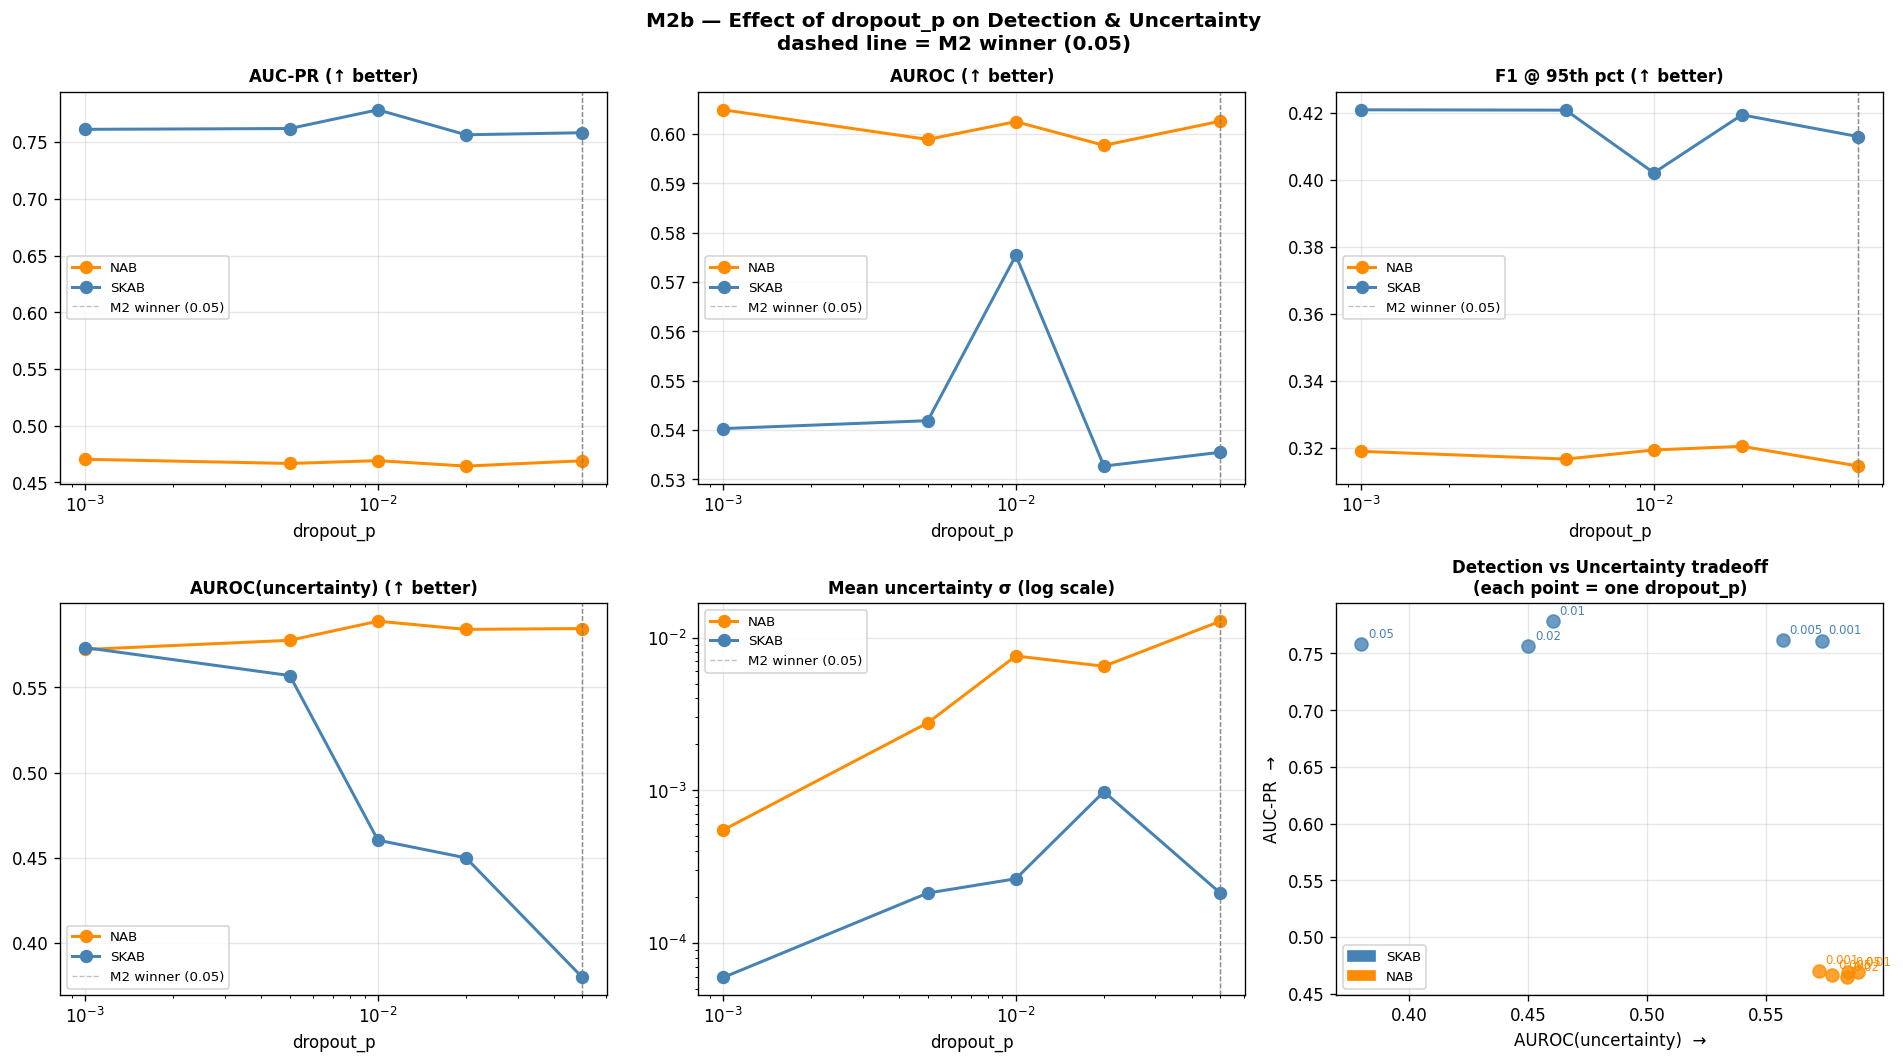

Saved outputs/m2b_dropout_tradeoff.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

METRICS = [
    ("auc_pr",    "AUC-PR (↑ better)",       "Greens"),
    ("auroc",     "AUROC (↑ better)",         "Blues"),
    ("f1",        "F1 @ 95th pct (↑ better)", "Oranges"),
    ("auroc_unc", "AUROC(uncertainty) (↑ better)", "Purples"),
    ("mean_unc",  "Mean uncertainty σ (log scale)", "Reds"),
]

colors_ds = {"SKAB": "steelblue", "NAB": "darkorange"}

for ax_idx, (metric_key, title, _) in enumerate(METRICS):
    ax = axes[ax_idx]
    for ds_name in sorted(sweep.keys()):
        entries = sorted(sweep[ds_name].values(), key=lambda x: x["dropout_p"])
        dps  = [e["dropout_p"] for e in entries]
        vals = [e["metrics"][metric_key] for e in entries]
        ax.plot(dps, vals, "o-", lw=1.8, ms=7,
                color=colors_ds[ds_name], label=ds_name)
        # mark M2 winner (dp=0.05)
        ref_idx = next((i for i,e in enumerate(entries) if abs(e["dropout_p"]-0.05)<1e-9), None)
        if ref_idx is not None:
            ax.axvline(0.05, color="grey", ls="--", lw=0.8, alpha=0.5)

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("dropout_p")
    ax.set_xscale("log")
    if metric_key == "mean_unc":
        ax.set_yscale("log")
    ax.axvline(0.05, color="grey", ls="--", lw=0.8, alpha=0.5,
               label="M2 winner (0.05)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# 6th subplot: combined tradeoff (AUC-PR vs AUROC_unc, one point per dropout)
ax = axes[5]
for ds_name in sorted(sweep.keys()):
    entries = sorted(sweep[ds_name].values(), key=lambda x: x["dropout_p"])
    for e in entries:
        dp  = e["dropout_p"]
        x   = e["metrics"]["auroc_unc"]
        y   = e["metrics"]["auc_pr"]
        ax.scatter(x, y, s=60, color=colors_ds[ds_name],
                   alpha=0.8, zorder=3)
        ax.annotate(f"{dp}", (x, y), textcoords="offset points",
                    xytext=(4, 4), fontsize=7,
                    color=colors_ds[ds_name])

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=d) for d, c in colors_ds.items()],
          fontsize=8)
ax.set_xlabel("AUROC(uncertainty)  →")
ax.set_ylabel("AUC-PR  →")
ax.set_title("Detection vs Uncertainty tradeoff\n(each point = one dropout_p)",
             fontsize=10, fontweight="bold")
ax.grid(True, alpha=0.3)

fig.suptitle("M2b — Effect of dropout_p on Detection & Uncertainty\n"
             "dashed line = M2 winner (0.05)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
path = f"{OUTPUT_DIR}/m2b_dropout_tradeoff.png"
plt.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved {path}")

---
## Section 6 — Save Best & Update Results

In [14]:
# Find best dropout per dataset (by AUC-PR — our primary metric)
best_per_ds = {}
for ds_name in sorted(sweep.keys()):
    entries = sorted(sweep[ds_name].values(), key=lambda x: -x["metrics"]["auc_pr"])
    best    = entries[0]
    best_per_ds[ds_name] = best
    print(f"{ds_name}  best dropout_p={best['dropout_p']}  "
          f"AUC-PR={best['metrics']['auc_pr']:.4f}  "
          f"AUROC(unc)={best['metrics']['auroc_unc']:.4f}")

# Save to baseline_results.json
try:
    with open(RESULTS_FILE) as f:
        all_results = json.load(f)
except FileNotFoundError:
    all_results = {}

for ds_name, best in best_per_ds.items():
    if ds_name not in all_results:
        all_results[ds_name] = {}
    all_results[ds_name]["M2b_lstm_mcd_lowdrop"] = {
        "dropout_p":  best["dropout_p"],
        "fixed_hp":   FIXED_HP[ds_name],
        "hidden_dim": LSTM_HIDDEN_DIM,
        "metrics":    best["metrics"],
        "val_loss":   best["val_loss"],
    }

with open(RESULTS_FILE, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"\nSaved → {RESULTS_FILE}")
print("Keys:", {ds: list(all_results[ds].keys()) for ds in all_results})

NAB  best dropout_p=0.001  AUC-PR=0.4704  AUROC(unc)=0.5723
SKAB  best dropout_p=0.01  AUC-PR=0.7784  AUROC(unc)=0.4604

Saved → outputs/baseline_results.json
Keys: {'NAB': ['M2b_lstm_mcd_lowdrop'], 'SKAB': ['M2b_lstm_mcd_lowdrop']}


In [15]:
print("=" * 72)
print("  M2b — Low-Dropout Ablation  FINAL SUMMARY")
print("=" * 72)

try:
    with open(RESULTS_FILE) as f:
        saved = json.load(f)
except FileNotFoundError:
    saved = {}

for ds_name in sorted(sweep.keys()):
    entries = sorted(sweep[ds_name].values(), key=lambda x: x["dropout_p"])
    m2_s    = saved.get(ds_name, {}).get("M2_lstm_mcd", {}).get("metrics", {})

    print(f"\n  {ds_name}  (latent_dim={FIXED_HP[ds_name]['latent_dim']}  lr=1e-3)")
    print(f"  {'dp':>7}  {'AUC-PR':>8}  {'AUROC(unc)':>11}  {'mean_unc':>10}  {'vs M2 AUC-PR':>13}")
    print(f"  {'─'*60}")

    m2_ap = m2_s.get("auc_pr", float("nan"))
    for e in entries:
        dp    = e["dropout_p"]
        m     = e["metrics"]
        delta = m["auc_pr"] - m2_ap if not (m2_ap != m2_ap) else float("nan")
        sign  = "+" if delta >= 0 else ""
        ref   = " ← M2" if abs(dp - 0.05) < 1e-9 else ""
        print(f"  {dp:>7.3f}  {m['auc_pr']:>8.4f}  {m['auroc_unc']:>11.4f}  "
              f"{m['mean_unc']:>10.2e}  {sign}{delta:>12.4f}{ref}")

print("\n" + "=" * 72)
print(f"  Plots   → {OUTPUT_DIR}/m2b_dropout_tradeoff.png")
print(f"  Results → {RESULTS_FILE}")
print("=" * 72)

  M2b — Low-Dropout Ablation  FINAL SUMMARY

  NAB  (latent_dim=64  lr=1e-3)
       dp    AUC-PR   AUROC(unc)    mean_unc   vs M2 AUC-PR
  ────────────────────────────────────────────────────────────
    0.001    0.4704       0.5723    5.50e-04           nan
    0.005    0.4667       0.5777    2.77e-03           nan
    0.010    0.4692       0.5889    7.59e-03           nan
    0.020    0.4644       0.5841    6.49e-03           nan
    0.050    0.4691       0.5846    1.28e-02           nan ← M2

  SKAB  (latent_dim=32  lr=1e-3)
       dp    AUC-PR   AUROC(unc)    mean_unc   vs M2 AUC-PR
  ────────────────────────────────────────────────────────────
    0.001    0.7612       0.5734    5.95e-05           nan
    0.005    0.7619       0.5570    2.12e-04           nan
    0.010    0.7784       0.4604    2.64e-04           nan
    0.020    0.7564       0.4500    9.80e-04           nan
    0.050    0.7582       0.3798    2.12e-04           nan ← M2

  Plots   → outputs/m2b_dropout_tradeoff.p